# 01 — Data exploration

Skeleton notebook for inspecting the USDA refrigerated truck rates snapshot.

Prerequisite: `python scripts/download_usda_data.py`

**Naming:** `raw_dataset` is the full API snapshot. The lane-week panel built in the modeling audit (Section 3) is the same population later formalized as `base_dataset` in notebook 02 via `build_lane_week_panel()`.


## Load raw USDA snapshot (`raw_dataset`)


In [129]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from freight_rates.ingestion import add_lane_id, load_raw_snapshot

ROOT = Path("..").resolve()
raw_dataset = load_raw_snapshot(raw_dir=ROOT / "data" / "raw")
raw_dataset.head()


,date,week,month,quarter,year,region,origin,destination,distance,commodity,weeklow,weekhigh,midpoint,rpm,availability
0,2024-07-02T00:00:00.000,26,6,2,2024,ARIZONA,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",ATLANTA,2100,"CELERY, SWEET CORN, BELL PEPPERS",5300,7300,6050,2.880952381,3
1,2024-07-02T00:00:00.000,26,6,2,2024,ARIZONA,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",BALTIMORE,2600,"CELERY, SWEET CORN, BELL PEPPERS",7100,8500,8050,3.0961538462,3
2,2024-07-02T00:00:00.000,26,6,2,2024,ARIZONA,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",CHICAGO,2030,"CELERY, SWEET CORN, BELL PEPPERS",4500,5900,5100,2.5123152709,3
3,2024-07-02T00:00:00.000,26,6,2,2024,ARIZONA,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",NEW YORK,2700,"CELERY, SWEET CORN, BELL PEPPERS",7200,8200,7900,2.9259259259,3
4,2024-07-02T00:00:00.000,26,6,2,2024,ARIZONA,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",SEATTLE,1300,"CELERY, SWEET CORN, BELL PEPPERS",2400,4100,3500,2.6923076923,3


## Dataset shape


In [130]:
raw_dataset.shape


(9043, 15)

In [131]:
sorted(raw_dataset.date.unique(), reverse=True)

['2026-08-18T00:00:00.000',
 '2026-08-11T00:00:00.000',
 '2026-08-04T00:00:00.000',
 '2026-07-28T00:00:00.000',
 '2026-07-21T00:00:00.000',
 '2026-07-14T00:00:00.000',
 '2026-07-07T00:00:00.000',
 '2026-06-30T00:00:00.000',
 '2026-06-23T00:00:00.000',
 '2026-06-16T00:00:00.000',
 '2026-06-09T00:00:00.000',
 '2026-06-02T00:00:00.000',
 '2026-05-26T00:00:00.000',
 '2026-05-19T00:00:00.000',
 '2026-05-12T00:00:00.000',
 '2026-05-05T00:00:00.000',
 '2026-04-28T00:00:00.000',
 '2026-04-21T00:00:00.000',
 '2026-04-14T00:00:00.000',
 '2026-04-07T00:00:00.000',
 '2026-03-31T00:00:00.000',
 '2026-03-24T00:00:00.000',
 '2026-03-17T00:00:00.000',
 '2026-03-10T00:00:00.000',
 '2026-03-03T00:00:00.000',
 '2026-02-24T00:00:00.000',
 '2026-02-17T00:00:00.000',
 '2026-02-10T00:00:00.000',
 '2026-02-03T00:00:00.000',
 '2026-01-27T00:00:00.000',
 '2026-01-20T00:00:00.000',
 '2026-01-13T00:00:00.000',
 '2026-01-06T00:00:00.000',
 '2025-12-30T00:00:00.000',
 '2025-12-16T00:00:00.000',
 '2025-12-09T00:00:0

## Schema


In [132]:
raw_dataset.dtypes


date            str
week            str
month           str
quarter         str
year            str
region          str
origin          str
destination     str
distance        str
commodity       str
weeklow         str
weekhigh        str
midpoint        str
rpm             str
availability    str
dtype: object

## Missing values


In [133]:
raw_dataset.isna().sum().sort_values(ascending=False)


rpm             516
distance        476
weekhigh         40
midpoint         40
date              0
week              0
month             0
quarter           0
year              0
region            0
origin            0
destination       0
commodity         0
weeklow           0
availability      0
dtype: int64

## Date coverage


In [134]:
dates = pd.to_datetime(raw_dataset["date"], errors="coerce")
print(f"min: {dates.min()}")
print(f"max: {dates.max()}")
print(f"unique dates: {dates.nunique()}")


min: 2024-07-02 00:00:00
max: 2026-08-18 00:00:00
unique dates: 110


## Origins and destinations


In [135]:
print(f"origins: {raw_dataset['origin'].nunique()}")
print(f"destinations: {raw_dataset['destination'].nunique()}")
raw_dataset["origin"].value_counts().head(10)


origins: 31
destinations: 10


origin
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON                                                          1099
SOUTH AND CENTRAL DISTRICT CALIFORNIA                                                                      978
MEXICO CROSSINGS THROUGH SOUTH TEXAS                                                                       837
IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WESTERN AZ, MEXICO CROSSINGS THROUGH CALEXICO AND SAN LUIS     650
MEXICO CROSSINGS THROUGH NOGALES, ARIZONA                                                                  562
SANTA MARIA CALIFORNIA                                                                                     494
NEW YORK                                                                                                   470
VIDALIA DISTRICT GEORGIA                                                                                   450
UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO                                                           

## Unique lanes


In [136]:
lanes = add_lane_id(raw_dataset)
print(f"unique lanes: {lanes['lane_id'].nunique()}")
lanes["lane_id"].value_counts().head(10)


unique lanes: 195


lane_id
IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WESTERN AZ, MEXICO CROSSINGS THROUGH CALEXICO AND SAN LUIS -> NEW YORK     118
IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WESTERN AZ, MEXICO CROSSINGS THROUGH CALEXICO AND SAN LUIS -> BALTIMORE    110
OXNARD DISTRICT CALIFORNIA -> BALTIMORE                                                                                110
SOUTH AND CENTRAL DISTRICT CALIFORNIA -> BALTIMORE                                                                     110
SOUTH AND CENTRAL DISTRICT CALIFORNIA -> PHILADELPHIA                                                                  110
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> ATLANTA                                                            110
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> BALTIMORE                                                          110
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> BOSTON                                                             110
YAKIMA V

## Observations per lane


In [137]:
obs_per_lane = lanes["lane_id"].value_counts()
obs_per_lane.describe()


count    195.000000
mean      46.374359
std       38.237974
min        1.000000
25%        9.000000
50%       43.000000
75%       77.000000
max      118.000000
Name: count, dtype: float64

## Distribution of rate per mile


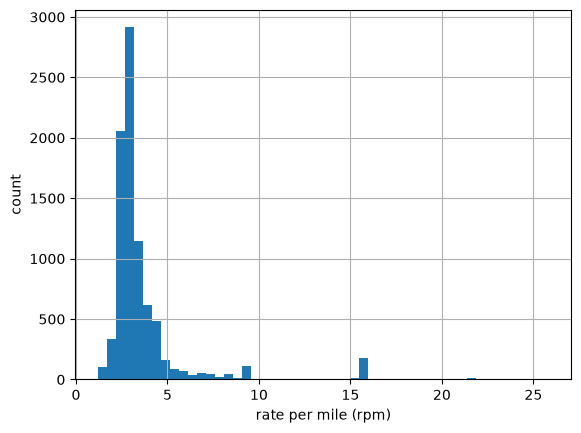

count    8527.000000
mean        3.607519
std         2.479256
min         1.187500
25%         2.618182
50%         2.907407
75%         3.576923
max        25.833333
Name: rpm, dtype: float64

In [138]:
rpm = pd.to_numeric(raw_dataset["rpm"], errors="coerce")
ax = rpm.dropna().hist(bins=50)
ax.set_xlabel("rate per mile (rpm)")
ax.set_ylabel("count")
plt.show()
rpm.describe()


## Modeling Audit: Dataset Grain

Investigate what one row actually represents by testing candidate key uniqueness.


In [139]:
import numpy as np

# Numeric coercion for audit sections (reuse loaded `raw_dataset`)
audit = raw_dataset.copy()
audit["date"] = pd.to_datetime(audit["date"], errors="coerce")
for col in ["distance", "weeklow", "weekhigh", "midpoint", "rpm", "availability"]:
    audit[col] = pd.to_numeric(audit[col], errors="coerce")

n_rows = len(audit)
candidate_grains = {
    "date + origin + destination": ["date", "origin", "destination"],
    "date + origin + destination + commodity": ["date", "origin", "destination", "commodity"],
    "date + region + origin + destination": ["date", "region", "origin", "destination"],
    "date + region + origin + destination + commodity": [
        "date", "region", "origin", "destination", "commodity"
    ],
}

grain_rows = []
for label, cols in candidate_grains.items():
    n_unique = audit.drop_duplicates(subset=cols).shape[0]
    n_dup = n_rows - n_unique
    grain_rows.append(
        {
            "candidate_grain": label,
            "total_rows": n_rows,
            "unique_combinations": n_unique,
            "duplicated_row_count": n_dup,
            "duplication_pct": 100.0 * n_dup / n_rows,
        }
    )

grain_table = pd.DataFrame(grain_rows).sort_values("duplication_pct")
grain_table

# Data-driven grain conclusion from uniqueness table
zero_dup = grain_table.loc[grain_table["duplication_pct"] == 0.0, "candidate_grain"]
if len(zero_dup) == 1:
    print(f"Likely dataset grain: {zero_dup.iloc[0]} (unique key; 0% duplication)")
elif len(zero_dup) > 1:
    print("Likely dataset grain candidates with 0% duplication:")
    print("\n".join(f"- {g}" for g in zero_dup))
else:
    best = grain_table.iloc[0]
    print(
        f"Likely dataset grain: {best['candidate_grain']} "
        f"(lowest duplication: {best['duplication_pct']:.2f}%)"
    )

grain_table


Likely dataset grain candidates with 0% duplication:
- date + region + origin + destination
- date + region + origin + destination + commodity


,candidate_grain,total_rows,unique_combinations,duplicated_row_count,duplication_pct
2,date + region + origin + destination,9043,9043,0,0.00000
3,date + region + origin + destination + commodity,9043,9043,0,0.00000
0,date + origin + destination,9043,8718,325,3.59394
1,date + origin + destination + commodity,9043,8718,325,3.59394


In [140]:
lane_week_cols = ["date", "origin", "destination"]
rows_per_lane_week = (
    audit.groupby(lane_week_cols, dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

q = rows_per_lane_week["n_rows"].quantile([0.25, 0.5, 0.75, 0.90])
lane_week_row_stats = pd.Series(
    {
        "mean": rows_per_lane_week["n_rows"].mean(),
        "median": q.loc[0.50],
        "p25": q.loc[0.25],
        "p75": q.loc[0.75],
        "p90": q.loc[0.90],
        "max": rows_per_lane_week["n_rows"].max(),
    }
)
print("Rows per date + origin + destination")
display(lane_week_row_stats.to_frame("value"))

top20_lane_weeks = rows_per_lane_week.sort_values("n_rows", ascending=False).head(20)
top20_lane_weeks


Rows per date + origin + destination


,value
mean,1.037279
median,1.000000
p25,1.000000
p75,1.000000
p90,1.000000
max,2.000000


,date,origin,destination,n_rows
2846,2025-01-21,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",NEW YORK,2
224,2024-07-16,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",CHICAGO,2
3592,2025-03-25,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",NEW YORK,2
3591,2025-03-25,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",BALTIMORE,2
2661,2025-01-07,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",NEW YORK,2
2660,2025-01-07,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",CHICAGO,2
2659,2025-01-07,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",ATLANTA,2
8342,2026-07-21,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",ATLANTA,2
8343,2026-07-21,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",BALTIMORE,2
8344,2026-07-21,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",BOSTON,2


Interpretation is printed above from the uniqueness table (no manual guess). Region/commodity often create extra raw rows for the same lane-week rate; the commodity-duplication audit quantifies whether those rows are independent.


## Commodity Duplication Audit

For each lane-week, check whether multiple commodity (and region) rows carry the same freight-rate observation.


In [141]:
lane_week_dup = (
    audit.groupby(lane_week_cols, dropna=False)
    .agg(
        n_rows=("commodity", "size"),
        n_commodities=("commodity", "nunique"),
        n_unique_rpm=("rpm", "nunique"),
        n_unique_midpoint=("midpoint", "nunique"),
        n_unique_weeklow=("weeklow", "nunique"),
        n_unique_weekhigh=("weekhigh", "nunique"),
    )
    .reset_index()
)

n_lw = len(lane_week_dup)
pct_unique_rpm_1 = 100.0 * (lane_week_dup["n_unique_rpm"] == 1).mean()
pct_unique_mid_1 = 100.0 * (lane_week_dup["n_unique_midpoint"] == 1).mean()
pct_multi_same_rpm = 100.0 * (
    (lane_week_dup["n_rows"] > 1) & (lane_week_dup["n_unique_rpm"] == 1)
).mean()
pct_commodities_vary_rpm_same = 100.0 * (
    (lane_week_dup["n_commodities"] > 1) & (lane_week_dup["n_unique_rpm"] == 1)
).mean()

commodity_dup_summary = pd.Series(
    {
        "pct_lane_weeks_unique_rpm_eq_1": pct_unique_rpm_1,
        "pct_lane_weeks_unique_midpoint_eq_1": pct_unique_mid_1,
        "pct_lane_weeks_rows_gt_1_and_unique_rpm_eq_1": pct_multi_same_rpm,
        "pct_lane_weeks_commodities_vary_but_rpm_does_not": pct_commodities_vary_rpm_same,
    }
)
commodity_dup_summary.to_frame("value")


,value
pct_lane_weeks_unique_rpm_eq_1,94.081211
pct_lane_weeks_unique_midpoint_eq_1,99.541179
pct_lane_weeks_rows_gt_1_and_unique_rpm_eq_1,3.727919
pct_lane_weeks_commodities_vary_but_rpm_does_not,0.000000


In [142]:
# Examples: multiple commodities, identical RPM
same_rpm_keys = lane_week_dup[
    (lane_week_dup["n_commodities"] > 1) & (lane_week_dup["n_unique_rpm"] == 1)
][lane_week_cols].head(10)

same_rpm_examples = (
    same_rpm_keys.merge(audit, on=lane_week_cols, how="left")
    .loc[:, lane_week_cols + ["region", "commodity", "weeklow", "weekhigh", "midpoint", "rpm"]]
    .sort_values(lane_week_cols + ["commodity"])
)
print("Multiple commodities with identical RPM (up to 10 lane-weeks):")
display(same_rpm_examples)

# Examples: multiple commodities, different RPM
diff_rpm_keys = lane_week_dup[
    (lane_week_dup["n_commodities"] > 1) & (lane_week_dup["n_unique_rpm"] > 1)
][lane_week_cols].head(10)

diff_rpm_examples = (
    diff_rpm_keys.merge(audit, on=lane_week_cols, how="left")
    .loc[:, lane_week_cols + ["region", "commodity", "weeklow", "weekhigh", "midpoint", "rpm"]]
    .sort_values(lane_week_cols + ["commodity"])
)
print("Multiple commodities with different RPM (up to 10 lane-weeks):")
display(diff_rpm_examples)
print(f"Lane-weeks with commodity variation and differing RPM: "
      f"{((lane_week_dup['n_commodities'] > 1) & (lane_week_dup['n_unique_rpm'] > 1)).sum():,}")


Multiple commodities with identical RPM (up to 10 lane-weeks):


,date,origin,destination,region,commodity,weeklow,weekhigh,midpoint,rpm


Multiple commodities with different RPM (up to 10 lane-weeks):


,date,origin,destination,region,commodity,weeklow,weekhigh,midpoint,rpm


Lane-weeks with commodity variation and differing RPM: 0


**Interpretation:** The large majority of lane-weeks have a single RPM value. When multiple rows share a lane-week, they often repeat the same rate across commodities and/or regions. Treating every raw row as an independent observation would **artificially inflate sample size**. Collapse to lane-week (or explicitly model commodity only where RPM truly differs) before fitting.


## Effective Lane-Week Dataset (`base_dataset` grain)

Build an in-memory diagnostic dataset at `date + origin + destination`. Same population as **`base_dataset`** in notebook 02 (`build_lane_week_panel()`). Do not write to `data/processed` yet.


In [143]:
lane_week = (
    audit.groupby(lane_week_cols, dropna=False)
    .agg(
        raw_rows_in_group=("commodity", "size"),
        commodity_count=("commodity", "nunique"),
        region_count=("region", "nunique"),
        region=("region", "first"),
        year=("year", "first"),
        week=("week", "first"),
        distance=("distance", "median"),
        weeklow=("weeklow", "median"),
        weekhigh=("weekhigh", "median"),
        midpoint=("midpoint", "median"),
        availability=("availability", "median"),
        rpm_nunique=("rpm", "nunique"),
        rpm_unique=("rpm", "first"),
        rpm_median=("rpm", "median"),
    )
    .reset_index()
)

lane_week["rpm_conflict"] = lane_week["rpm_nunique"] > 1
lane_week["rpm"] = np.where(
    lane_week["rpm_conflict"],
    lane_week["rpm_median"],
    lane_week["rpm_unique"],
)
lane_week["lane_id"] = lane_week["origin"] + " -> " + lane_week["destination"]

raw_n = len(audit)
lw_n = len(lane_week)
n_conflict = int(lane_week["rpm_conflict"].sum())

effective_summary = pd.Series(
    {
        "raw_row_count": raw_n,
        "lane_week_row_count": lw_n,
        "reduction_pct": 100.0 * (1 - lw_n / raw_n),
        "rpm_conflict_count": n_conflict,
        "rpm_conflict_pct": 100.0 * n_conflict / lw_n,
    }
)
display(effective_summary.to_frame("value"))

obs_per_lane_eff = lane_week.groupby("lane_id").size()
q_lane = obs_per_lane_eff.quantile([0.25, 0.5, 0.75, 0.90])
lane_obs_stats = pd.Series(
    {
        "unique_lanes": obs_per_lane_eff.shape[0],
        "mean_obs_per_lane": obs_per_lane_eff.mean(),
        "median": q_lane.loc[0.50],
        "p25": q_lane.loc[0.25],
        "p75": q_lane.loc[0.75],
        "p90": q_lane.loc[0.90],
        "max": obs_per_lane_eff.max(),
    }
)
print("Observations per lane (effective lane-week grain)")
lane_obs_stats.to_frame("value")


,value
raw_row_count,9043.00000
lane_week_row_count,8718.00000
reduction_pct,3.59394
rpm_conflict_count,0.00000
rpm_conflict_pct,0.00000


Observations per lane (effective lane-week grain)


,value
unique_lanes,195.000000
mean_obs_per_lane,44.707692
median,43.000000
p25,9.000000
p75,63.000000
p90,109.000000
max,110.000000


In [144]:
lane_week.loc[lane_week.rpm_conflict==True, lane_week_cols + ['week','rpm',"rpm_conflict", "rpm_median", "rpm_unique"]].sort_values(by= ['origin', 'destination', 'week']).head(30)


,date,origin,destination,week,rpm,rpm_conflict,rpm_median,rpm_unique


In [145]:
lane_week[[ 'date', 'week']]


,date,week
0,2024-07-02,26
1,2024-07-02,26
2,2024-07-02,26
3,2024-07-02,26
4,2024-07-02,26
...,...,...
8713,2026-08-18,33
8714,2026-08-18,33
8715,2026-08-18,33
8716,2026-08-18,33


**Interpretation:** The raw ~206k rows compress to substantially fewer lane-week observations after collapsing reporting duplicates. The original table does **not** represent ~206k independent rate draws; independence should be assessed at the lane-week (and lane) level.


## RPM Outlier Audit

Analyze the target distribution, extremes, and relationship with distance.


In [146]:
rpm_s = audit["rpm"].dropna()
rpm_quantiles = rpm_s.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
rpm_dist = pd.Series(
    {
        "min": rpm_s.min(),
        "p1": rpm_quantiles.loc[0.01],
        "p5": rpm_quantiles.loc[0.05],
        "p25": rpm_quantiles.loc[0.25],
        "median": rpm_quantiles.loc[0.50],
        "p75": rpm_quantiles.loc[0.75],
        "p95": rpm_quantiles.loc[0.95],
        "p99": rpm_quantiles.loc[0.99],
        "max": rpm_s.max(),
    }
)
rpm_dist.to_frame("rpm")


,rpm
min,1.187500
p1,1.640000
p5,2.167832
p25,2.618182
median,2.907407
p75,3.576923
p95,7.500000
p99,15.666667
max,25.833333


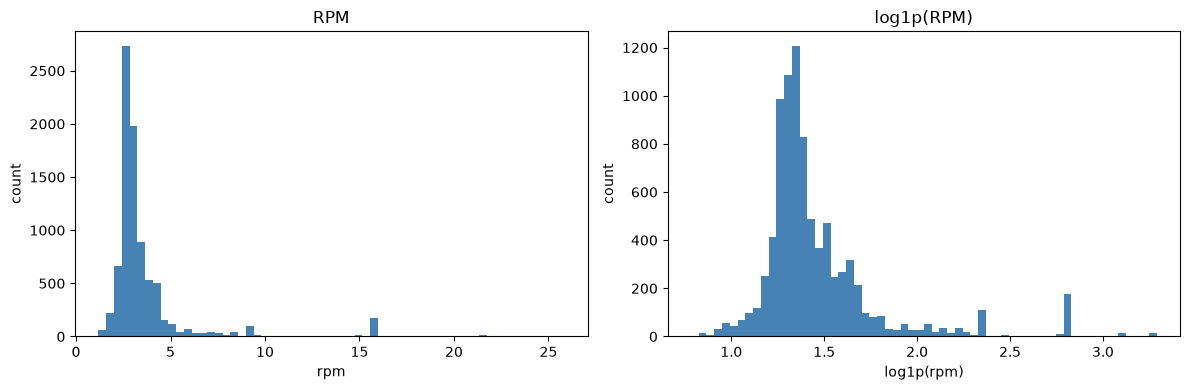

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rpm_s, bins=60, color="steelblue", edgecolor="none")
axes[0].set_title("RPM")
axes[0].set_xlabel("rpm")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(rpm_s), bins=60, color="steelblue", edgecolor="none")
axes[1].set_title("log1p(RPM)")
axes[1].set_xlabel("log1p(rpm)")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


In [148]:
top30_rpm = (
    audit.sort_values("rpm", ascending=False)
    .loc[
        :,
        [
            "date", "origin", "destination", "distance",
            "weeklow", "weekhigh", "midpoint", "rpm",
            "availability", "commodity",
        ],
    ]
    .head(30)
)
top30_rpm


,date,origin,destination,distance,weeklow,weekhigh,midpoint,rpm,availability,commodity
1172,2024-09-17,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
959,2024-09-03,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
747,2024-08-20,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
531,2024-08-06,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
1280,2024-09-24,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
639,2024-08-13,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
1064,2024-09-10,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
854,2024-08-27,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1550.0,25.833333,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
325,2024-07-23,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2000.0,1500.0,25.000000,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."
428,2024-07-30,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1000.0,2100.0,1500.0,25.000000,3,"ARTICHOKES, BRUSSELS SPROUTS, CABBAGE, CELERY,..."


Pearson(rpm, distance):  -0.4897
Spearman(rpm, distance): -0.3815


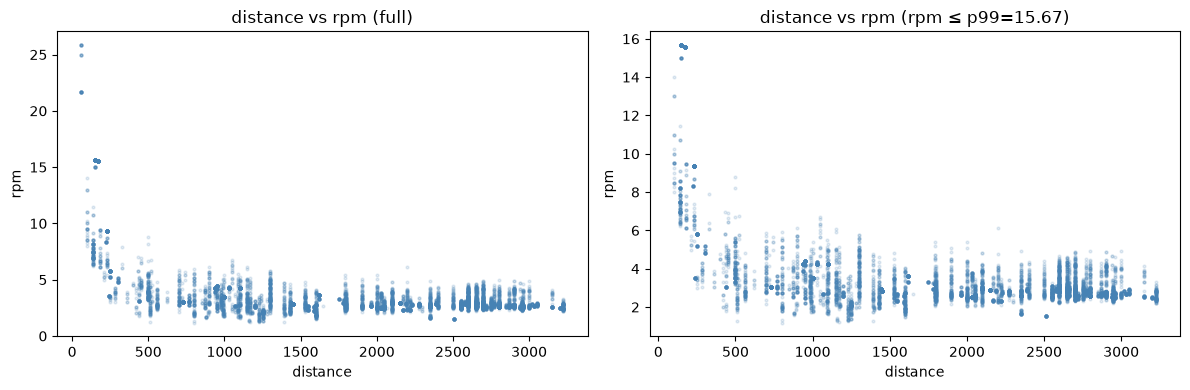

In [149]:
corr_df = audit[["rpm", "distance"]].dropna()
pearson = corr_df["rpm"].corr(corr_df["distance"], method="pearson")
spearman = corr_df["rpm"].corr(corr_df["distance"], method="spearman")
print(f"Pearson(rpm, distance):  {pearson:.4f}")
print(f"Spearman(rpm, distance): {spearman:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(corr_df["distance"], corr_df["rpm"], s=4, alpha=0.15, color="steelblue")
axes[0].set_title("distance vs rpm (full)")
axes[0].set_xlabel("distance")
axes[0].set_ylabel("rpm")

# Zoom: exclude extreme RPM tail for readability
rpm_p99 = corr_df["rpm"].quantile(0.99)
zoom = corr_df[corr_df["rpm"] <= rpm_p99]
axes[1].scatter(zoom["distance"], zoom["rpm"], s=4, alpha=0.15, color="steelblue")
axes[1].set_title(f"distance vs rpm (rpm ≤ p99={rpm_p99:.2f})")
axes[1].set_xlabel("distance")
axes[1].set_ylabel("rpm")
plt.tight_layout()
plt.show()


In [150]:
bins = [0, 100, 250, 500, 1000, 2000, np.inf]
labels = ["0–100", "100–250", "250–500", "500–1000", "1000–2000", "2000+"]
dist_bucket = pd.cut(audit["distance"], bins=bins, labels=labels, right=False)

rpm_by_dist = (
    audit.assign(distance_bucket=dist_bucket)
    .groupby("distance_bucket", observed=False)["rpm"]
    .agg(count="count", median="median", mean="mean", p95=lambda s: s.quantile(0.95))
)
rpm_by_dist


,count,median,mean,p95
distance_bucket,,,,
0–100,27,21.666667,23.518519,25.833333
100–250,552,9.347826,10.504634,15.666667
250–500,212,4.708333,4.534604,5.813953
500–1000,1064,3.300000,3.455936,5.166667
1000–2000,2314,2.867133,3.019058,4.503431
2000+,4358,2.800000,2.914917,4.038462


**Are extreme RPM values primarily associated with short-distance movements, or do they appear to be data-quality issues?**

Extreme RPM values concentrate in the shortest distance buckets (notably under ~100 miles), where a typical truckload dollar rate divided by a small mileage produces very large $/mile. The negative RPM–distance correlation and the top-RPM examples (short hauls with ordinary absolute rates) support a **short-haul arithmetic effect**, not random corruption. Still treat ultra-short lanes carefully in modeling (separate regime, transform, or exclusion policy), but they are explainable rather than pure data-entry noise.


## Lane Sparsity and Cold-Start Readiness

Using the effective lane-week dataset, profile how many historical observations each lane has.


In [151]:
lane_counts = (
    lane_week.groupby("lane_id")
    .size()
    .rename("n_obs")
    .reset_index()
    .sort_values("n_obs", ascending=False)
)

bucket_edges = [1, 5, 20, 100, 500, np.inf]
bucket_labels = ["1–4", "5–19", "20–99", "100–499", "500+"]
lane_counts["bucket"] = pd.cut(
    lane_counts["n_obs"],
    bins=bucket_edges,
    labels=bucket_labels,
    right=False,
    include_lowest=True,
)

n_lanes = len(lane_counts)
n_obs_total = int(lane_counts["n_obs"].sum())

sparsity = (
    lane_counts.groupby("bucket", observed=False)
    .agg(n_lanes=("lane_id", "size"), total_observations=("n_obs", "sum"))
    .assign(
        pct_lanes=lambda d: 100.0 * d["n_lanes"] / n_lanes,
        pct_observations=lambda d: 100.0 * d["total_observations"] / n_obs_total,
    )
)
display(sparsity)

thresholds = pd.Series(
    {
        "lanes_<5": int((lane_counts["n_obs"] < 5).sum()),
        "lanes_<20": int((lane_counts["n_obs"] < 20).sum()),
        "lanes_>=20": int((lane_counts["n_obs"] >= 20).sum()),
        "lanes_>=100": int((lane_counts["n_obs"] >= 100).sum()),
        "lanes_>=500": int((lane_counts["n_obs"] >= 500).sum()),
    }
)
thresholds.to_frame("count")


,n_lanes,total_observations,pct_lanes,pct_observations
bucket,,,,
1–4,23,53,11.794872,0.607938
5–19,42,374,21.538462,4.289975
20–99,100,5020,51.282051,57.582014
100–499,30,3271,15.384615,37.520073
500+,0,0,0.000000,0.000000


,count
lanes_<5,23
lanes_<20,65
lanes_>=20,130
lanes_>=100,30
lanes_>=500,0


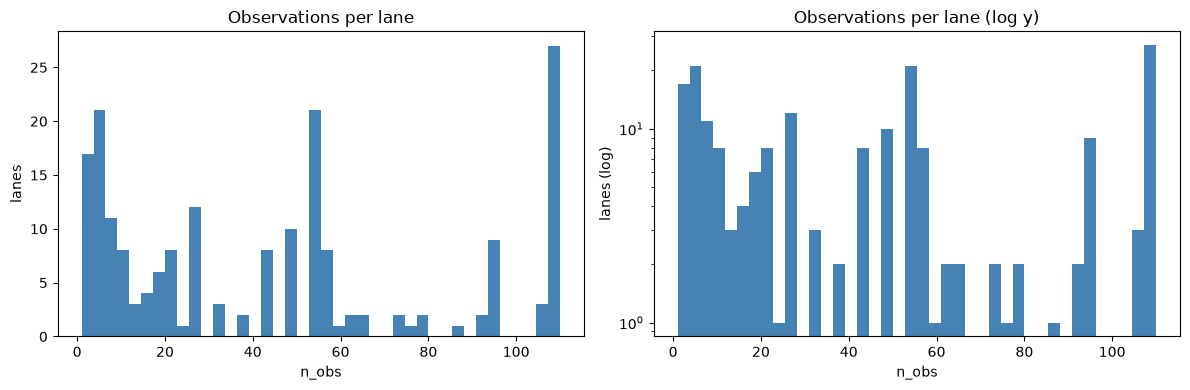

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lane_counts["n_obs"], bins=40, color="steelblue", edgecolor="none")
axes[0].set_title("Observations per lane")
axes[0].set_xlabel("n_obs")
axes[0].set_ylabel("lanes")

axes[1].hist(lane_counts["n_obs"], bins=40, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_title("Observations per lane (log y)")
axes[1].set_xlabel("n_obs")
axes[1].set_ylabel("lanes (log)")
plt.tight_layout()
plt.show()


**Does this dataset contain enough sparse and mature lanes to evaluate cold-start behavior at n = 0, 5, 20, and 100?**

- **n = 0:** No true zero-history prediction targets exist until a lane first appears; evaluate by **withholding complete lanes** from training (synthetic cold start).
- **n = 5 / 20 / 100:** Viable if enough lanes have *at least* that many historical lane-weeks **plus** later weeks for evaluation. The sparsity table shows both a sparse tail (<5, <20) and a mature core (≥100, and often ≥500). That mix supports cold-start protocols at those thresholds, combining natural sparse lanes with controlled holdouts for n = 0.


## Lane Coverage Over Time

Track when lanes first appear, how long they persist, and how coverage grows by year.


In [153]:
lane_span = (
    lane_week.groupby("lane_id")
    .agg(
        first_seen_date=("date", "min"),
        last_seen_date=("date", "max"),
        total_observations=("date", "size"),
    )
    .reset_index()
    .sort_values("first_seen_date")
)

lane_week = lane_week.copy()
lane_week["year_int"] = lane_week["date"].dt.year

years = sorted(lane_week["year_int"].dropna().unique())
coverage_rows = []
seen = set()
for y in years:
    yr = lane_week[lane_week["year_int"] == y]
    active = set(yr["lane_id"].unique())
    new = active - seen
    seen |= active
    coverage_rows.append(
        {
            "year": int(y),
            "active_lanes": len(active),
            "new_lanes": len(new),
            "cumulative_unique_lanes": len(seen),
            "n_observations": len(yr),
        }
    )

coverage_by_year = pd.DataFrame(coverage_rows)
coverage_by_year


,year,active_lanes,new_lanes,cumulative_unique_lanes,n_observations
0,2024,144,144,144,2640
1,2025,151,41,185,3815
2,2026,106,10,195,2263


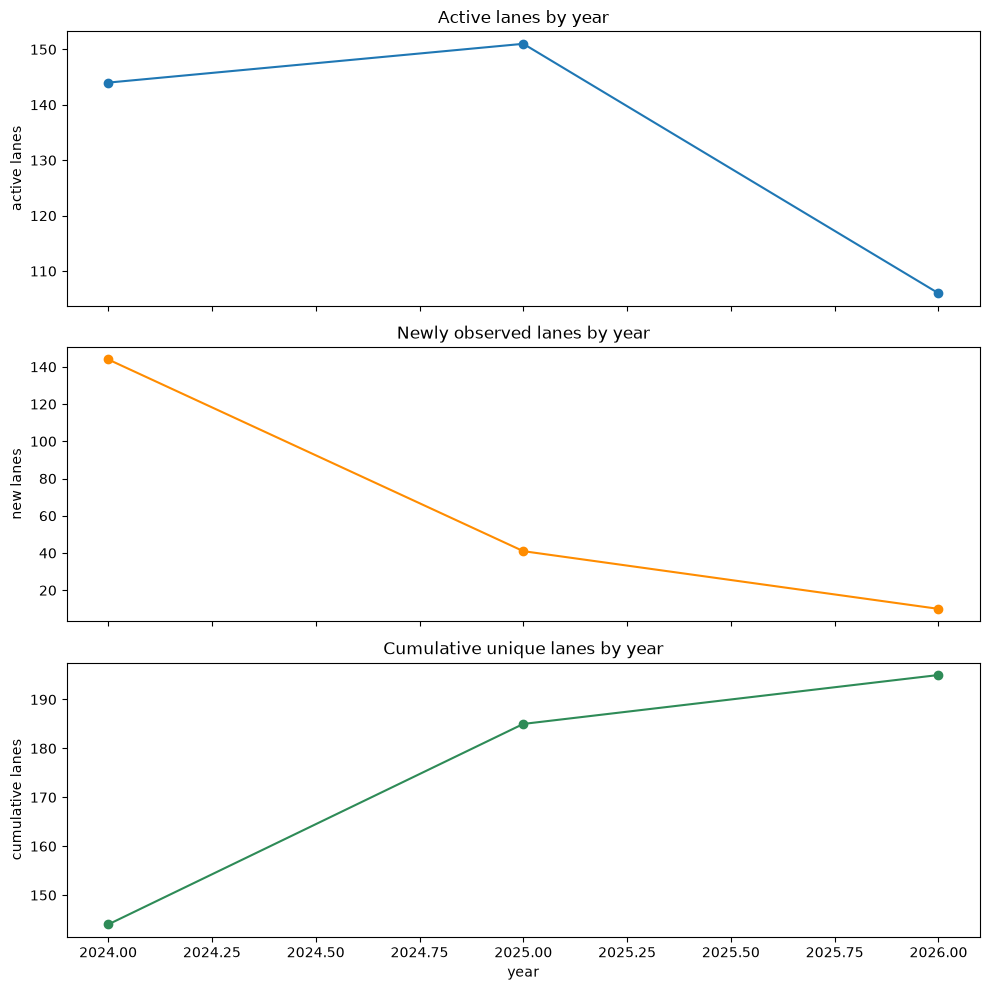

,lane_id,first_seen_date,last_seen_date,total_observations
95,NORTH CAROLINA -> PHILADELPHIA,2026-07-28,2026-08-18,4
94,NORTH CAROLINA -> NEW YORK,2026-07-28,2026-08-18,4
90,NORTH CAROLINA -> ATLANTA,2026-07-28,2026-08-18,4
91,NORTH CAROLINA -> BALTIMORE,2026-07-28,2026-08-18,4
92,NORTH CAROLINA -> BOSTON,2026-07-28,2026-08-18,4
93,NORTH CAROLINA -> CHICAGO,2026-07-28,2026-08-18,4
137,SANTA MARIA CALIFORNIA -> SEATTLE,2026-05-12,2026-08-18,15
50,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",2026-04-28,2026-08-18,17
48,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",2026-04-28,2026-08-18,17
51,"IMPERIAL, COACHELLA VALLEYS CA, CENTRAL AND WE...",2026-04-28,2026-08-18,17


In [154]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(coverage_by_year["year"], coverage_by_year["active_lanes"], marker="o")
axes[0].set_ylabel("active lanes")
axes[0].set_title("Active lanes by year")

axes[1].plot(coverage_by_year["year"], coverage_by_year["new_lanes"], marker="o", color="darkorange")
axes[1].set_ylabel("new lanes")
axes[1].set_title("Newly observed lanes by year")

axes[2].plot(coverage_by_year["year"], coverage_by_year["cumulative_unique_lanes"], marker="o", color="seagreen")
axes[2].set_ylabel("cumulative lanes")
axes[2].set_xlabel("year")
axes[2].set_title("Cumulative unique lanes by year")
plt.tight_layout()
plt.show()

recent20 = lane_span.sort_values("first_seen_date", ascending=False).head(20)
recent20


**Interpretation:** Some lanes appear early and persist for decades; others enter late or have brief coverage. Late `first_seen_date` lanes are **natural cold-start candidates** when subsequent weeks exist for evaluation. Brief one-off lanes are less useful for multi-threshold protocols. Overall, cold start should use **both** natural late/sparse lanes and **synthetic full-lane holdouts** for true n = 0.


## Target Leakage Audit

Verify whether RPM is reconstructible from midpoint and distance, and whether midpoint equals the weekly low/high average.


In [155]:
leak = audit.dropna(subset=["rpm", "midpoint", "distance"]).copy()
leak = leak[leak["distance"] != 0]
leak["rpm_reconstructed"] = leak["midpoint"] / leak["distance"]
leak["rpm_abs_error"] = (leak["rpm"] - leak["rpm_reconstructed"]).abs()

rpm_leak_stats = pd.Series(
    {
        "mean_abs_error": leak["rpm_abs_error"].mean(),
        "median_error": leak["rpm_abs_error"].median(),
        "p95_error": leak["rpm_abs_error"].quantile(0.95),
        "max_error": leak["rpm_abs_error"].max(),
        "pct_within_1e-6": 100.0 * (leak["rpm_abs_error"] <= 1e-6).mean(),
        "n_rows_checked": len(leak),
    }
)
print("rpm ≈ midpoint / distance")
display(rpm_leak_stats.to_frame("value"))

mid = audit.dropna(subset=["midpoint", "weeklow", "weekhigh"]).copy()
mid["mid_reconstructed"] = (mid["weeklow"] + mid["weekhigh"]) / 2.0
mid["mid_abs_error"] = (mid["midpoint"] - mid["mid_reconstructed"]).abs()

mid_leak_stats = pd.Series(
    {
        "mean_abs_error": mid["mid_abs_error"].mean(),
        "median_error": mid["mid_abs_error"].median(),
        "p95_error": mid["mid_abs_error"].quantile(0.95),
        "max_error": mid["mid_abs_error"].max(),
        "pct_within_1e-6": 100.0 * (mid["mid_abs_error"] <= 1e-6).mean(),
        "n_rows_checked": len(mid),
    }
)
print("midpoint ≈ (weeklow + weekhigh) / 2")
mid_leak_stats.to_frame("value")


rpm ≈ midpoint / distance


,value
mean_abs_error,2.733821e-11
median_error,2.222222e-11
p95_error,4.761924e-11
max_error,4.285710e-10
pct_within_1e-6,1.000000e+02
n_rows_checked,8.527000e+03


midpoint ≈ (weeklow + weekhigh) / 2


,value
mean_abs_error,50.246281
median_error,0.000000
p95_error,250.000000
max_error,3630.000000
pct_within_1e-6,68.299456
n_rows_checked,9003.000000


**Leakage conclusion**

- **`weeklow`, `weekhigh`, `midpoint`:** Clear leakage if RPM is the target. RPM reconstructs as `midpoint / distance` within floating-point tolerance on essentially all valid rows; midpoint/low/high are the same week's published rate information and would not be known before the rate is observed.
- **`distance`:** Not leakage by itself. It participates in the RPM definition, but mileages are typically known (or estimable) at quoting time. Using distance as a feature is legitimate; using midpoint/low/high is not.

Do **not** include `weeklow`, `weekhigh`, or `midpoint` as model inputs when predicting RPM.


## Modeling-Readiness Summary


In [156]:
summary = pd.Series(
    {
        "raw_rows": raw_n,
        "effective_lane_week_rows": lw_n,
        "date_range": f"{audit['date'].min().date()} → {audit['date'].max().date()}",
        "unique_origins": raw_dataset["origin"].nunique(),
        "unique_destinations": raw_dataset["destination"].nunique(),
        "unique_lanes": int(lane_obs_stats["unique_lanes"]),
        "median_obs_per_lane": float(lane_obs_stats["median"]),
        "lanes_<5_obs": int(thresholds["lanes_<5"]),
        "lanes_<20_obs": int(thresholds["lanes_<20"]),
        "lanes_>=100_obs": int(thresholds["lanes_>=100"]),
        "pct_duplicated_commodity_rate_rows": float(pct_multi_same_rpm),
        "pct_rpm_conflicts_within_lane_week": float(effective_summary["rpm_conflict_pct"]),
        "rpm_p99": float(rpm_dist["p99"]),
        "rpm_max": float(rpm_dist["max"]),
    }
)
summary.to_frame("value")


,value
raw_rows,9043
effective_lane_week_rows,8718
date_range,2024-07-02 → 2026-08-18
unique_origins,31
unique_destinations,10
unique_lanes,195
median_obs_per_lane,43.0
lanes_<5_obs,23
lanes_<20_obs,65
lanes_>=100_obs,30


### Answers

1. **What should one modeling observation represent?** One **lane-week**: `date + origin + destination` (effective rate observation after collapsing reporting duplicates).

2. **Should commodity-level duplicate rows be collapsed?** **Yes**, when they share the same RPM (the common case). Retain commodity as a feature or separate series only where RPM truly differs within the lane-week.

3. **Is RPM a reasonable initial target?** **Yes**, as a distance-normalized rate. Be aware of short-haul inflation of $/mile; consider log transforms and/or distance-aware evaluation.

4. **Which columns are clear leakage?** `weeklow`, `weekhigh`, and `midpoint`. `distance` is a legitimate pre-shipment feature if known at prediction time.

5. **Suitable for a global Gradient Boosting model?** **Yes** — many lanes, long history, and rich OD structure after collapsing to lane-weeks. Need careful leakage control and lane-aware validation.

6. **Suitable for a hierarchical Bayesian cold-start experiment?** **Yes** — mix of sparse and mature lanes supports partial pooling; hierarchy over lane (and possibly origin/destination) is natural.

7. **Cold start: natural, synthetic, or both?** **Both** — use late-appearing / sparse lanes where possible, and simulate n = 0 by withholding entire lanes.

8. **Next modeling step (no fitting yet):** Define the **processed lane-week panel** (collapse rules, RPM conflict policy, short-haul handling) and a **lane-aware train/validation protocol** for cold-start thresholds n ∈ {0, 5, 20, 100} before any model training.
